In [ ]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import HTML
import random
import joblib
from datetime import datetime
import time
import requests
import pickle
from google.colab import drive
import glob
import shutil

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score, accuracy_score
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
import fasttext.util
import pickle
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import randint, uniform
from sklearn.metrics import roc_curve, auc
from torch.utils.data import WeightedRandomSampler

# Настройки
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
random.seed(42)
np.random.seed(42)

In [3]:
# Импортируем данные
file_id = '1YRPhDgamWCaZJnr90dUJipKWiAhyjv2H'
url = f'https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t'

data = pd.read_csv(url)
data.head()

,Unnamed: 0,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal,swearing,has_positive_emoji,has_negative_emoji,has_obscene_emoji,imperative,2nd_prsn_count,3nd_prsn_count,adj_count,vocative,expr_punct
0,0,INSULT,скотина! что сказать,скотина сказать,скотина что сказать,20,3,5.67,False,False,False,False,False,False,0,0,0,True,False
1,1,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...,180,28,5.21,True,False,False,False,False,False,0,0,3,False,False
2,2,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...,379,54,5.78,True,False,False,False,False,False,0,0,8,False,True
3,3,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...,72,10,5.70,True,False,False,False,False,False,0,0,0,False,True
4,4,NORMAL,а когда мы статус агрогородка получили?,статус агрогородка получили,а когда мы статус агрогородка получили,39,6,5.50,True,False,False,False,False,False,0,0,0,False,False


In [4]:
df = data.copy()
df = df[['label', 'comment', 'cleaned_comment', 'comment_without_punct']]
df['cleaned_comment'] = np.where(df['cleaned_comment'].isna(), df['comment_without_punct'], df['cleaned_comment'])

In [5]:
# Разобьем данные на X и y
X = df['comment_without_punct'].astype(str).tolist()
y = df['label']

In [6]:
# Для моделей будем использовать численные классы
le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Classes:', list(le.classes_))

# Разделим выборку на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_enc
)

print('Train size:', len(X_train), 'Test size:', len(X_test))

Classes: ['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']
Train size: 198624 Test size: 49657


In [7]:
# Векторизация FastText
'''
# Скачиваем модель fasttext
fasttext.util.download_model('ru', if_exists='ignore')
ft = fasttext.load_model('cc.ru.300.bin')

# Проверим размер файла
file_size = os.path.getsize('cc.ru.300.bin') / (1024 ** 3)
print(f'Размер файла: {file_size:.2f} GB')

def fasttext_embeddings(comments, max_len=30):
    embeddings = []
    zero_vector = np.zeros(300)
    for comment in comments:
        words = comment.split()[:max_len]
        vectors = [ft.get_word_vector(word) for word in words]

        if len(vectors) < max_len:
            vectors += [zero_vector] * (max_len - len(vectors))

        embeddings.append(vectors)
    return np.array(embeddings, dtype=np.float32)

def process_embedding(comments, batch_size, desc):
    result = []
    for i in tqdm(range(0, len(comments), batch_size), desc=desc):
        batch_comments = comments[i:i + batch_size]
        batch_embeddings = fasttext_embeddings(batch_comments)
        result.extend(batch_embeddings)

    return np.array(result, dtype=np.float32)

# Найдем эмбеддинги
X_vectors_train = process_embedding(X_train, batch_size=500, desc='Векторизация train')
X_vectors_test = process_embedding(X_test, batch_size=1000, desc='Векторизация test')

print('X_vectors_train:', X_vectors_train.shape)
print('X_vectors_test:', X_vectors_test.shape)


# Сохраняем с метаданными
dataset = {
    'X_vectors_train': X_vectors_train,
    'y_train': y_train,
    'X_vectors_test': X_vectors_test,
    'y_test': y_test,

    'X_train': X_train,
    'X_test': X_test,

    'metadata': {
        'max_len': 30,
        'embedding_dim': 300,
        'classes': list(le.classes_),
        'n_classes': len(le.classes_),
        'train_size': len(y_train),
        'test_size': len(y_test),
        'created_at': str(datetime.now()),
        'random_state': RANDOM_STATE,
        'has_text': True
    }
}

# Сохраняем
joblib.dump(dataset, 'toxicity_dataset.joblib', compress=3)
'''

"\n# Скачиваем модель fasttext\nfasttext.util.download_model('ru', if_exists='ignore')\nft = fasttext.load_model('cc.ru.300.bin')\n\n# Проверим размер файла\nfile_size = os.path.getsize('cc.ru.300.bin') / (1024 ** 3)\nprint(f'Размер файла: {file_size:.2f} GB')\n\ndef fasttext_embeddings(comments, max_len=30):\n    embeddings = []\n    zero_vector = np.zeros(300)\n    for comment in comments:\n        words = comment.split()[:max_len]\n        vectors = [ft.get_word_vector(word) for word in words]\n\n        if len(vectors) < max_len:\n            vectors += [zero_vector] * (max_len - len(vectors))\n\n        embeddings.append(vectors)\n    return np.array(embeddings, dtype=np.float32)\n\ndef process_embedding(comments, batch_size, desc):\n    result = []\n    for i in tqdm(range(0, len(comments), batch_size), desc=desc):\n        batch_comments = comments[i:i + batch_size]\n        batch_embeddings = fasttext_embeddings(batch_comments)\n        result.extend(batch_embeddings)\n\n    re

In [ ]:
drive.mount('/content/drive')
files = glob.glob('/content/drive/MyDrive/**/toxicity_dataset.joblib', recursive=True)

file_path = files[0]
shutil.copy(file_path, 'toxicity_dataset.joblib')
dataset = joblib.load('toxicity_dataset.joblib')

# Получаем данные
X_vectors_train = dataset['X_vectors_train']
y_train = dataset['y_train']
X_train = dataset['X_train']
X_vectors_test = dataset['X_vectors_test']
y_test = dataset['y_test']
X_test = dataset['X_test']

"\ndrive.mount('/content/drive')\nfiles = glob.glob('/content/drive/MyDrive/**/toxicity_dataset.joblib', recursive=True)\n\nfile_path = files[0]\nshutil.copy(file_path, 'toxicity_dataset.joblib')\ndataset = joblib.load('toxicity_dataset.joblib')\n\n# Получаем данные\nX_vectors_train = dataset['X_vectors_train']\ny_train = dataset['y_train']\nX_train = dataset['X_train']\nX_vectors_test = dataset['X_vectors_test']\ny_test = dataset['y_test']\nX_test = dataset['X_test']\n"

In [10]:
# ПОДГОТОВКА ДАННЫХ

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Конвертируем в тензоры
X_train_tensor = torch.FloatTensor(X_vectors_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_vectors_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Базовый DataLoader
train_loader_base = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

# WeightedRandomSampler
class_counts = np.bincount(y_train)
sample_weights = 1 / class_counts[y_train]
sample_weights = torch.FloatTensor(sample_weights)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
train_loader_weighted = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, sampler=sampler)

In [ ]:
# МОДЕЛЬ 1: VANILLA RNN (BASELINE)
# Характеристики:
# - Простая однослойная RNN
# - hidden_dim=32
# - Без dropout
# - Без балансировки классов
# - Обычный CrossEntropyLoss

class VanillaRNN(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=32, output_dim=4):
        super(VanillaRNN, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True, num_layers=1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model = VanillaRNN(output_dim=len(dataset['metadata']['classes'])).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ОБУЧЕНИЕ VANILLA RNN (BASELINE)")

start_time = time.time()

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_base:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_base):.4f}, F1-macro: {f1:.4f}")
train_time = time.time() - start_time

model.eval()
all_preds = []
inference_start = time.time()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ VANILLA RNN (BASELINE)")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

ОБУЧЕНИЕ VANILLA RNN (BASELINE)
Epoch 10/50, Loss: 0.6010, F1-macro: 0.3562
Epoch 20/50, Loss: 0.2167, F1-macro: 0.6077
Epoch 30/50, Loss: 0.1799, F1-macro: 0.6647
Epoch 40/50, Loss: 0.1690, F1-macro: 0.6813
Epoch 50/50, Loss: 0.1669, F1-macro: 0.7157

РЕЗУЛЬТАТЫ VANILLA RNN (BASELINE)
              precision    recall  f1-score   support

      INSULT       0.82      0.75      0.79      5713
      NORMAL       0.97      0.98      0.98     40736
   OBSCENITY       0.40      0.33      0.36       852
      THREAT       0.71      0.76      0.73      2356

    accuracy                           0.94     49657
   macro avg       0.73      0.71      0.72     49657
weighted avg       0.93      0.94      0.93     49657

F1-macro: 0.7157
Время обучения: 6.43 минут
Время инференса: 0.75 секунд


In [13]:
# Визуализация
def plot_pr_and_roc_torch(model, model_name, test_loader, label_encoder, device, figsize=(14, 5)):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    class_names = label_encoder.classes_
    classes = np.sort(np.unique(all_labels))
    y_bin = label_binarize(all_labels, classes=classes)
    n_classes = len(classes)

    fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=figsize)

    # ========== PR кривая ==========
    for i, cls in enumerate(classes):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
        ap = average_precision_score(y_bin[:, i], all_probs[:, i])
        class_name = class_names[cls] if cls < len(class_names) else f'Class_{cls}'
        ax_pr.plot(rec, prec, lw=2, label=f'{class_name} (AP={ap:.3f})')

    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'{model_name}\nPrecision-Recall Curves')
    ax_pr.legend(loc='best')
    ax_pr.grid(True, alpha=0.3)
    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])

    # ========== ROC кривая ==========
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        class_name = class_names[cls] if cls < len(class_names) else f'Class_{cls}'
        ax_roc.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={roc_auc:.3f})')

    # Macro-average для ROC
    try:
        roc_auc_macro = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
    except:
        roc_auc_macro = np.mean([auc(roc_curve(y_bin[:, i], all_probs[:, i])[0],
                                   roc_curve(y_bin[:, i], all_probs[:, i])[1]) for i in range(n_classes)])

    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'{model_name}\nROC Curves')
    ax_roc.legend(loc='lower right')
    ax_roc.grid(True, alpha=0.3)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.show()

    print(f"\n{model_name} - ROC Macro AUC: {roc_auc_macro:.4f}")

    print("\nМетрики по классам:")
    for i, cls in enumerate(classes):
        class_name = class_names[cls] if cls < len(class_names) else f'Class_{cls}'
        ap = average_precision_score(y_bin[:, i], all_probs[:, i])
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        print(f"{class_name}: AP={ap:.4f}, AUC={roc_auc:.4f}")


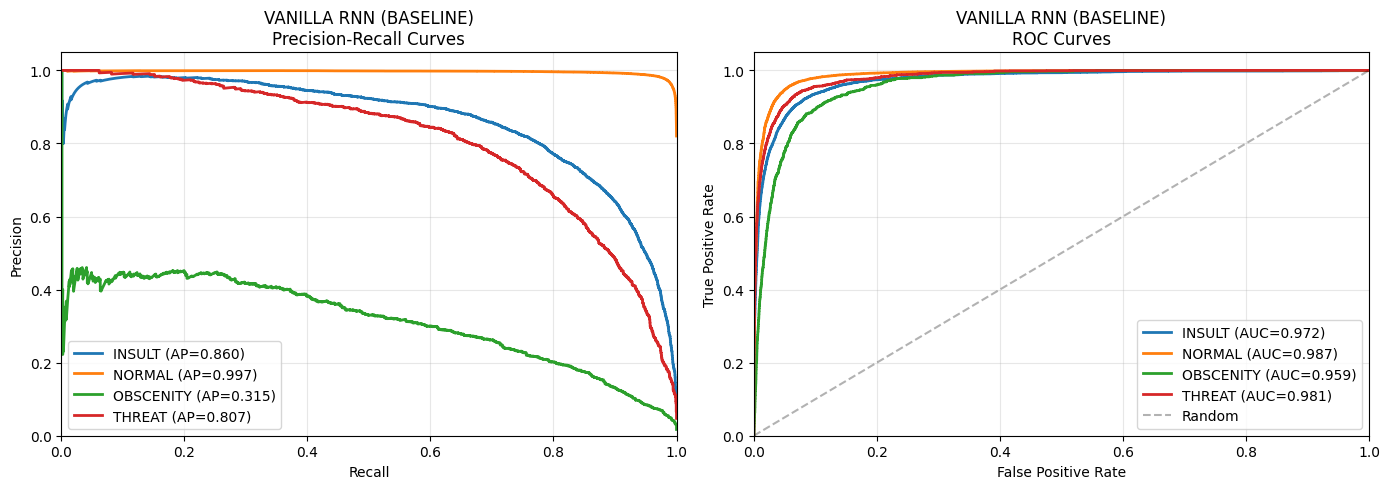


VANILLA RNN (BASELINE) - ROC Macro AUC: 0.9749

Метрики по классам:
INSULT: AP=0.8602, AUC=0.9725
NORMAL: AP=0.9965, AUC=0.9872
OBSCENITY: AP=0.3154, AUC=0.9595
THREAT: AP=0.8071, AUC=0.9806


In [ ]:
plot_pr_and_roc_torch(
    model=model,
    model_name='VANILLA RNN (BASELINE)',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)

In [ ]:
# МОДЕЛЬ 2: БАЗОВАЯ LSTM
# Характеристики:
# - 2 слоя LSTM (глубже чем RNN)
# - hidden_dim=128
# - Dropout=0.3 между слоями
# - Без балансировки классов
# - Обычный CrossEntropyLoss

class BasicLSTM(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=4):
        super(BasicLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=2, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

model = BasicLSTM(output_dim=len(dataset['metadata']['classes'])).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ОБУЧЕНИЕ БАЗОВОЙ LSTM")

start_time = time.time()
for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_base:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_base):.4f}, F1-macro: {f1:.4f}")
train_time = time.time() - start_time

model.eval()
all_preds = []
inference_start = time.time()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ БАЗОВОЙ LSTM")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

ОБУЧЕНИЕ БАЗОВОЙ LSTM
Epoch 10/50, Loss: 0.1217, F1-macro: 0.8523
Epoch 20/50, Loss: 0.0546, F1-macro: 0.8675
Epoch 30/50, Loss: 0.0233, F1-macro: 0.8535
Epoch 40/50, Loss: 0.0117, F1-macro: 0.8628
Epoch 50/50, Loss: 0.0081, F1-macro: 0.8600

РЕЗУЛЬТАТЫ БАЗОВОЙ LSTM
              precision    recall  f1-score   support

      INSULT       0.83      0.83      0.83      5713
      NORMAL       0.98      0.98      0.98     40736
   OBSCENITY       0.83      0.78      0.80       852
      THREAT       0.84      0.80      0.82      2356

    accuracy                           0.95     49657
   macro avg       0.87      0.85      0.86     49657
weighted avg       0.95      0.95      0.95     49657

F1-macro: 0.8600
Время обучения: 8.91 минут
Время инференса: 1.28 секунд


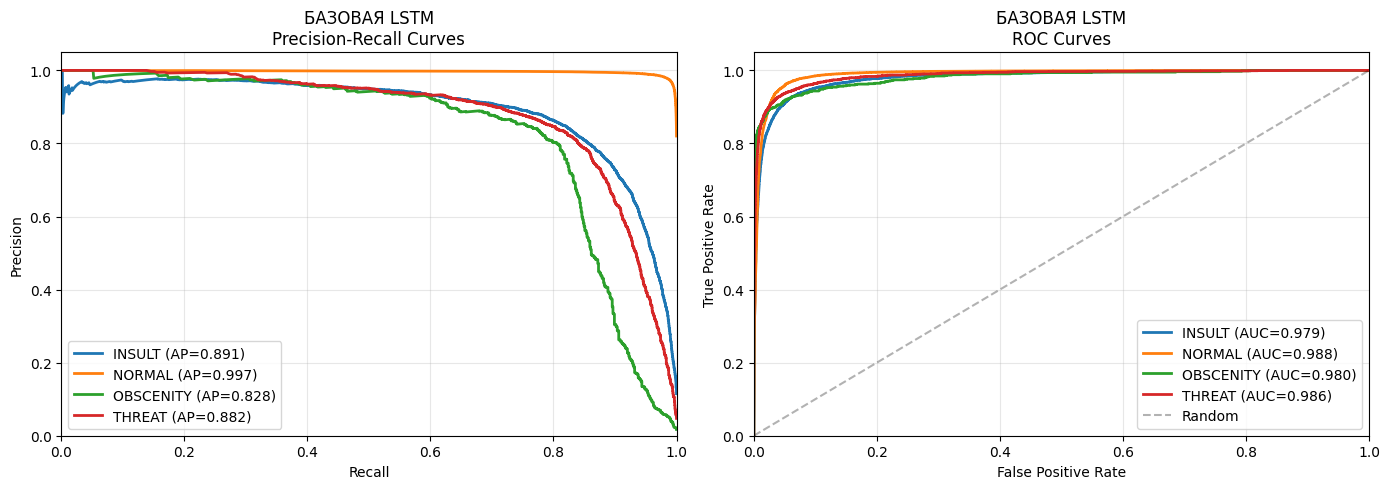


БАЗОВАЯ LSTM - ROC Macro AUC: 0.9832

Метрики по классам:
INSULT: AP=0.8914, AUC=0.9787
NORMAL: AP=0.9969, AUC=0.9884
OBSCENITY: AP=0.8282, AUC=0.9802
THREAT: AP=0.8819, AUC=0.9855


In [ ]:
plot_pr_and_roc_torch(
    model=model,
    model_name='БАЗОВАЯ LSTM',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)

In [ ]:
# МОДЕЛЬ 3: LSTM С БАЛАНСИРОВКОЙ КЛАССОВ
# Характеристики:
# - 2 слоя LSTM
# - hidden_dim=128
# - Dropout=0.3
# - WeightedRandomSampler для балансировки классов
# - Обычный CrossEntropyLoss

class BalancedLSTM(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=4):
        super(BalancedLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=2, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

model = BalancedLSTM(output_dim=len(dataset['metadata']['classes'])).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ОБУЧЕНИЕ LSTM С БАЛАНСИРОВКОЙ КЛАССОВ")

start_time = time.time()
for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_weighted:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_weighted):.4f}, F1-macro: {f1:.4f}")
train_time = time.time() - start_time

model.eval()
all_preds = []
inference_start = time.time()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ LSTM С БАЛАНСИРОВКОЙ КЛАССОВ")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

ОБУЧЕНИЕ LSTM С БАЛАНСИРОВКОЙ КЛАССОВ
Epoch 10/50, Loss: 0.0740, F1-macro: 0.8529
Epoch 20/50, Loss: 0.0335, F1-macro: 0.8599
Epoch 30/50, Loss: 0.0193, F1-macro: 0.8603
Epoch 40/50, Loss: 0.0145, F1-macro: 0.8676
Epoch 50/50, Loss: 0.0106, F1-macro: 0.8642

РЕЗУЛЬТАТЫ LSTM С БАЛАНСИРОВКОЙ КЛАССОВ
              precision    recall  f1-score   support

      INSULT       0.82      0.85      0.83      5713
      NORMAL       0.98      0.98      0.98     40736
   OBSCENITY       0.82      0.80      0.81       852
      THREAT       0.82      0.85      0.84      2356

    accuracy                           0.95     49657
   macro avg       0.86      0.87      0.86     49657
weighted avg       0.95      0.95      0.95     49657

F1-macro: 0.8642
Время обучения: 8.94 минут
Время инференса: 1.27 секунд


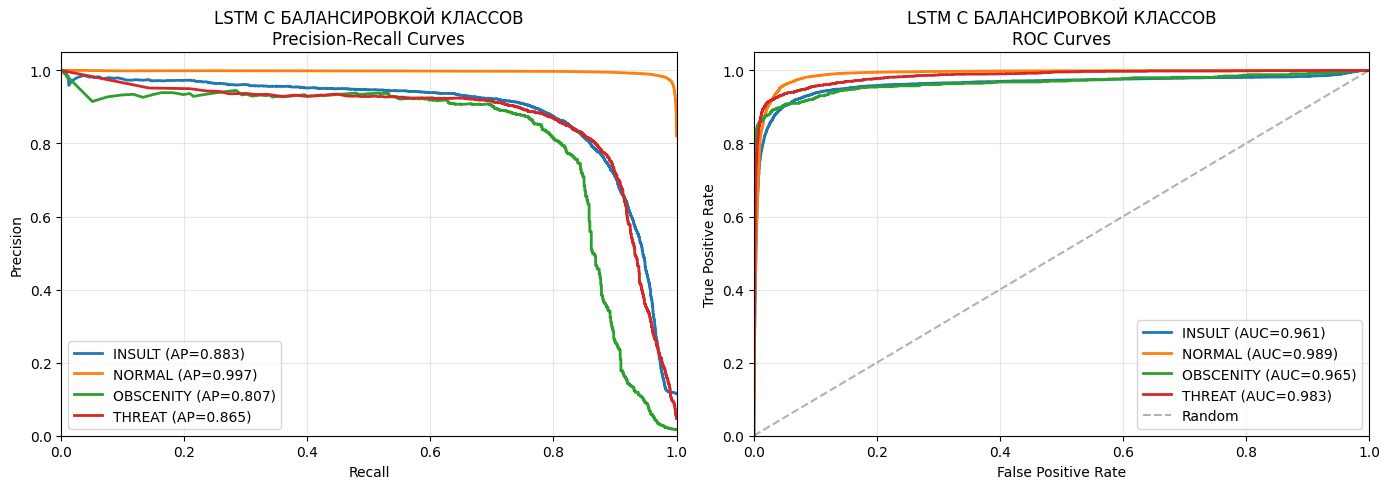


LSTM С БАЛАНСИРОВКОЙ КЛАССОВ - ROC Macro AUC: 0.9745

Метрики по классам:
INSULT: AP=0.8832, AUC=0.9613
NORMAL: AP=0.9970, AUC=0.9889
OBSCENITY: AP=0.8072, AUC=0.9646
THREAT: AP=0.8649, AUC=0.9833


In [ ]:
plot_pr_and_roc_torch(
    model=model,
    model_name='LSTM С БАЛАНСИРОВКОЙ КЛАССОВ',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)

In [ ]:
# МОДЕЛЬ 4: УЛУЧШЕННАЯ LSTM (БОЛЬШЕ СЛОЕВ)
# Характеристики:
# - 3 слоя LSTM (вместо 2)
# - hidden_dim=256 (вместо 128)
# - Dropout=0.4 (больше регуляризации)
# - Bidirectional = True (двунаправленная)
# - WeightedRandomSampler

class ImprovedLSTM(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=256, output_dim=4):
        super(ImprovedLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=3, dropout=0.4, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, output_dim)
        )
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

model = ImprovedLSTM(output_dim=len(dataset['metadata']['classes'])).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ОБУЧЕНИЕ УЛУЧШЕННОЙ LSTM (3 слоя, 256 нейронов, bidirectional)")

start_time = time.time()

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_weighted:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_weighted):.4f}, F1-macro: {f1:.4f}")

train_time = time.time() - start_time

model.eval()
inference_start = time.time()
all_preds = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ УЛУЧШЕННОЙ LSTM")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

ОБУЧЕНИЕ УЛУЧШЕННОЙ LSTM (3 слоя, 256 нейронов, bidirectional)
Epoch 10/50, Loss: 0.0478, F1-macro: 0.8447
Epoch 20/50, Loss: 0.0207, F1-macro: 0.8569
Epoch 30/50, Loss: 0.0136, F1-macro: 0.8649
Epoch 40/50, Loss: 0.0098, F1-macro: 0.8685
Epoch 50/50, Loss: 0.0075, F1-macro: 0.8680

РЕЗУЛЬТАТЫ УЛУЧШЕННОЙ LSTM
              precision    recall  f1-score   support

      INSULT       0.84      0.84      0.84      5713
      NORMAL       0.98      0.98      0.98     40736
   OBSCENITY       0.83      0.80      0.82       852
      THREAT       0.82      0.84      0.83      2356

    accuracy                           0.96     49657
   macro avg       0.87      0.87      0.87     49657
weighted avg       0.96      0.96      0.96     49657

F1-macro: 0.8680
Время обучения: 60.37 минут
Время инференса: 6.32 секунд


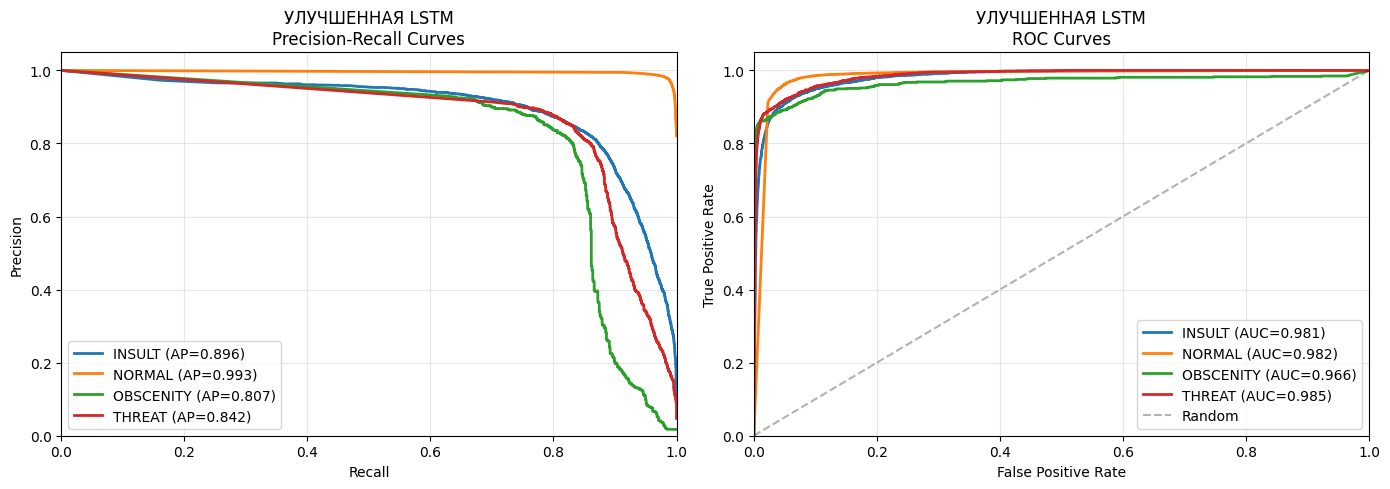


УЛУЧШЕННАЯ LSTM - ROC Macro AUC: 0.9784

Метрики по классам:
INSULT: AP=0.8960, AUC=0.9806
NORMAL: AP=0.9934, AUC=0.9822
OBSCENITY: AP=0.8070, AUC=0.9657
THREAT: AP=0.8421, AUC=0.9850


In [ ]:
plot_pr_and_roc_torch(
    model=model,
    model_name='УЛУЧШЕННАЯ LSTM',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)

In [11]:
# МОДЕЛЬ 5: УЛУЧШЕННАЯ LSTM С ВЕСАМИ В CrossEntropyLoss"
# Характеристики:
# - 3 слоя LSTM
# - hidden_dim=256
# - Dropout=0.4
# - Bidirectional = True
# - БЕЗ WeightedRandomSampler (обычный shuffle)
# - ТОЛЬКО веса в CrossEntropyLoss

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Веса классов:")
for cls, w in zip(dataset['metadata']['classes'], class_weights):
    print(f"{cls}: {w:.4f}")

class ImprovedLSTM(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=256, output_dim=4):
        super(ImprovedLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, num_layers=3, dropout=0.4, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, output_dim)
        )
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

model = ImprovedLSTM(output_dim=len(dataset['metadata']['classes'])).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nУЛУЧШЕННАЯ LSTM С ВЕСАМИ В CrossEntropyLoss")

start_time = time.time()

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_base:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_base):.4f}, F1-macro: {f1:.4f}")

train_time = time.time() - start_time

model.eval()
inference_start = time.time()
all_preds = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ УЛУЧШЕННОЙ LSTM С ВЕСАМИ В CrossEntropyLoss")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

Веса классов:
INSULT: 2.1728
NORMAL: 0.3047
OBSCENITY: 14.5661
THREAT: 5.2708

УЛУЧШЕННАЯ LSTM С ВЕСАМИ В CrossEntropyLoss
Epoch 10/50, Loss: 1.3865, F1-macro: 0.2319
Epoch 20/50, Loss: 1.3873, F1-macro: 0.2521
Epoch 30/50, Loss: 0.2497, F1-macro: 0.8467
Epoch 40/50, Loss: 0.1111, F1-macro: 0.8452
Epoch 50/50, Loss: 0.0640, F1-macro: 0.8546

РЕЗУЛЬТАТЫ УЛУЧШЕННОЙ LSTM С ВЕСАМИ В CrossEntropyLoss
              precision    recall  f1-score   support

      INSULT       0.80      0.85      0.82      5713
      NORMAL       0.98      0.97      0.98     40736
   OBSCENITY       0.80      0.78      0.79       852
      THREAT       0.81      0.84      0.82      2356

    accuracy                           0.95     49657
   macro avg       0.85      0.86      0.85     49657
weighted avg       0.95      0.95      0.95     49657

F1-macro: 0.8546
Время обучения: 11.85 минут
Время инференса: 1.08 секунд


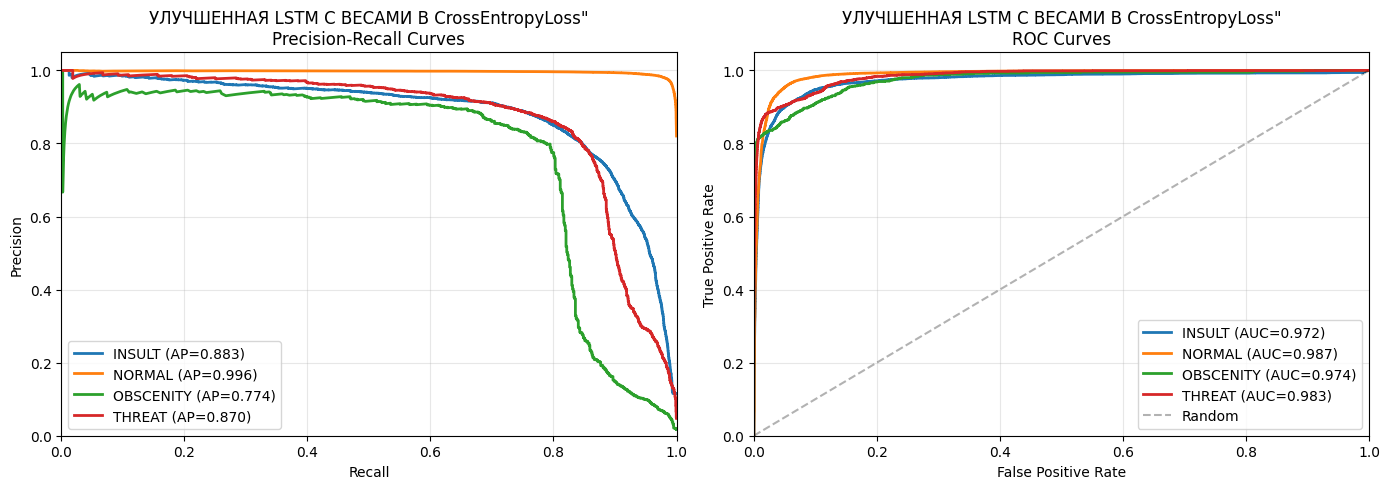


УЛУЧШЕННАЯ LSTM С ВЕСАМИ В CrossEntropyLoss" - ROC Macro AUC: 0.9792

Метрики по классам:
INSULT: AP=0.8833, AUC=0.9719
NORMAL: AP=0.9965, AUC=0.9873
OBSCENITY: AP=0.7742, AUC=0.9744
THREAT: AP=0.8699, AUC=0.9831


In [14]:
plot_pr_and_roc_torch(
    model=model,
    model_name='УЛУЧШЕННАЯ LSTM С ВЕСАМИ В CrossEntropyLoss"',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)

In [ ]:
# МОДЕЛЬ 6: БАЗОВАЯ GRU
# Характеристики:
# - 2 слоя GRU
# - hidden_dim=128
# - Dropout=0.3
# - Без балансировки классов

class BasicGRU(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=4):
        super(BasicGRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, num_layers=2, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

model = BasicGRU(output_dim=len(dataset['metadata']['classes'])).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ОБУЧЕНИЕ БАЗОВОЙ GRU")

start_time = time.time()

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_base:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_base):.4f}, F1-macro: {f1:.4f}")

train_time = time.time() - start_time

model.eval()
inference_start = time.time()
all_preds = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ БАЗОВОЙ GRU")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

ОБУЧЕНИЕ БАЗОВОЙ GRU
Epoch 10/50, Loss: 0.0647, F1-macro: 0.8636
Epoch 20/50, Loss: 0.0226, F1-macro: 0.8562
Epoch 30/50, Loss: 0.0134, F1-macro: 0.8574
Epoch 40/50, Loss: 0.0107, F1-macro: 0.8543
Epoch 50/50, Loss: 0.0080, F1-macro: 0.8590

РЕЗУЛЬТАТЫ БАЗОВОЙ GRU
              precision    recall  f1-score   support

      INSULT       0.83      0.84      0.83      5713
      NORMAL       0.98      0.98      0.98     40736
   OBSCENITY       0.79      0.80      0.79       852
      THREAT       0.84      0.82      0.83      2356

    accuracy                           0.95     49657
   macro avg       0.86      0.86      0.86     49657
weighted avg       0.95      0.95      0.95     49657

F1-macro: 0.8590
Время обучения: 2.59 минут
Время инференса: 0.29 секунд


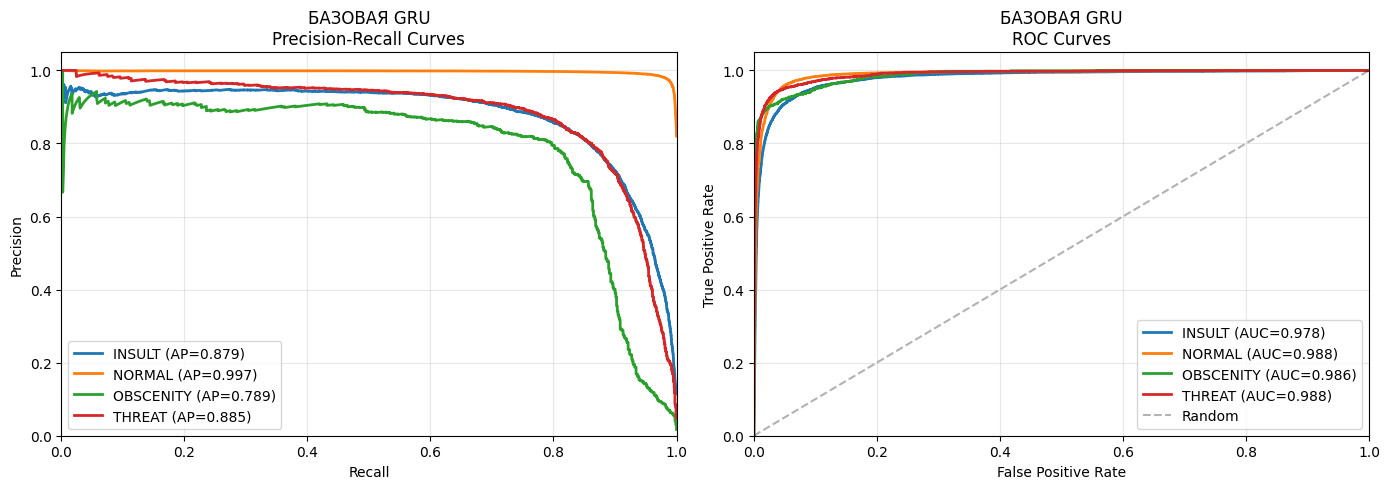


БАЗОВАЯ GRU - ROC Macro AUC: 0.9851

Метрики по классам:
INSULT: AP=0.8786, AUC=0.9783
NORMAL: AP=0.9967, AUC=0.9880
OBSCENITY: AP=0.7893, AUC=0.9857
THREAT: AP=0.8851, AUC=0.9884


In [16]:
plot_pr_and_roc_torch(
    model=model,
    model_name='БАЗОВАЯ GRU',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)

In [17]:
# МОДЕЛЬ 7: GRU С БАЛАНСИРОВКОЙ КЛАССОВ
# Характеристики:
# - 2 слоя GRU
# - hidden_dim=128
# - WeightedRandomSampler для балансировки
# - Dropout=0.3

class BalancedGRU(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=4):
        super(BalancedGRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, num_layers=2, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

model = BalancedGRU(output_dim=len(dataset['metadata']['classes'])).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ОБУЧЕНИЕ GRU С БАЛАНСИРОВКОЙ КЛАССОВ")

start_time = time.time()

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_weighted:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        all_preds = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
        f1 = f1_score(y_test, all_preds, average='macro')
        print(f"Epoch {epoch+1}/50, Loss: {total_loss/len(train_loader_weighted):.4f}, F1-macro: {f1:.4f}")

train_time = time.time() - start_time

model.eval()
inference_start = time.time()
all_preds = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
inference_time = time.time() - inference_start

print("\nРЕЗУЛЬТАТЫ GRU С БАЛАНСИРОВКОЙ КЛАССОВ")
print(classification_report(y_test, all_preds, target_names=dataset['metadata']['classes']))
print(f"F1-macro: {f1_score(y_test, all_preds, average='macro'):.4f}")
print(f"Время обучения: {train_time/60:.2f} минут")
print(f"Время инференса: {inference_time:.2f} секунд")

ОБУЧЕНИЕ GRU С БАЛАНСИРОВКОЙ КЛАССОВ
Epoch 10/50, Loss: 0.0573, F1-macro: 0.8544
Epoch 20/50, Loss: 0.0306, F1-macro: 0.8480
Epoch 30/50, Loss: 0.0226, F1-macro: 0.8505
Epoch 40/50, Loss: 0.0174, F1-macro: 0.8507
Epoch 50/50, Loss: 0.0166, F1-macro: 0.8575

РЕЗУЛЬТАТЫ GRU С БАЛАНСИРОВКОЙ КЛАССОВ
              precision    recall  f1-score   support

      INSULT       0.78      0.86      0.82      5713
      NORMAL       0.99      0.97      0.98     40736
   OBSCENITY       0.77      0.82      0.79       852
      THREAT       0.84      0.84      0.84      2356

    accuracy                           0.95     49657
   macro avg       0.84      0.87      0.86     49657
weighted avg       0.95      0.95      0.95     49657

F1-macro: 0.8575
Время обучения: 2.59 минут
Время инференса: 0.29 секунд


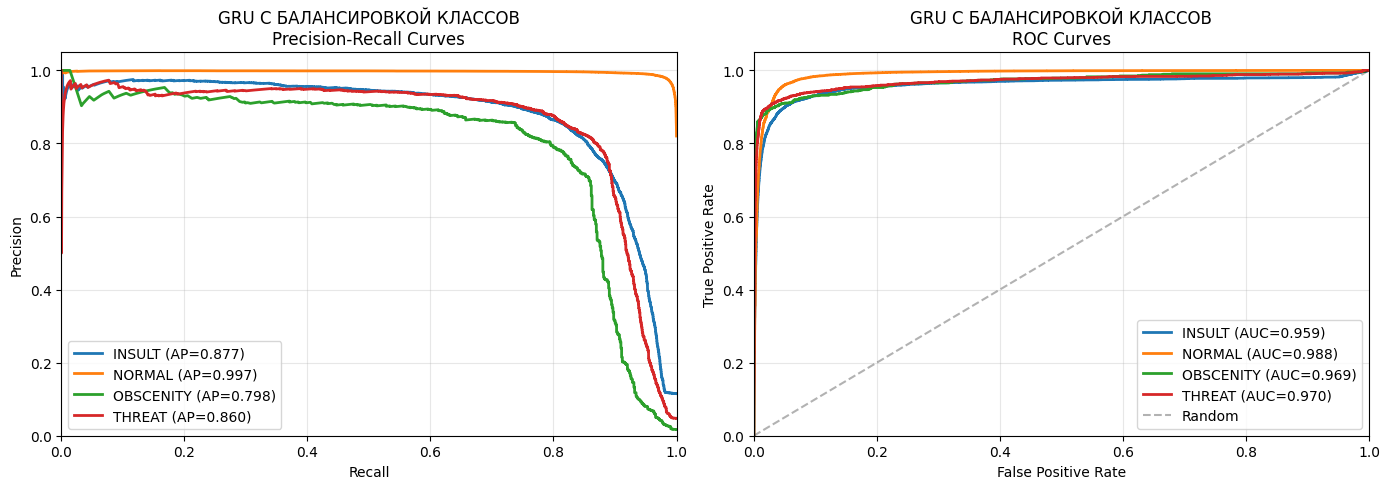


GRU С БАЛАНСИРОВКОЙ КЛАССОВ - ROC Macro AUC: 0.9714

Метрики по классам:
INSULT: AP=0.8773, AUC=0.9591
NORMAL: AP=0.9967, AUC=0.9881
OBSCENITY: AP=0.7982, AUC=0.9689
THREAT: AP=0.8597, AUC=0.9696


In [18]:
plot_pr_and_roc_torch(
    model=model,
    model_name='GRU С БАЛАНСИРОВКОЙ КЛАССОВ',
    test_loader=test_loader,
    label_encoder=le,
    device=device
)